In [51]:
import pandas as pd
import numpy as np
import pickle
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
from xgboost import XGBClassifier


In [52]:
path = "../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"

In [53]:
rna_hl_human = np.load( path + 'rna_hl_human.npz')

print(rna_hl_human.files)

print("\nArray shapes:")
print(f"X shape: {rna_hl_human['X'].shape}")
print(f"y shape: {rna_hl_human['y'].shape}")
print(f"genes shape: {rna_hl_human['genes'].shape}")

print(f"\nX dimensions: {rna_hl_human['X'].ndim}")
if rna_hl_human['X'].ndim == 3:
    print(f"X first sample shape: {rna_hl_human['X'][0].shape}")
    print(f"X first sample, first feature vector: {rna_hl_human['X'][0, 0, :5]}")  # First 5 features
elif rna_hl_human['X'].ndim == 2:
    print(f"X first sample (first 10 features): {rna_hl_human['X'][0, :10]}")


['X', 'y', 'genes']

Array shapes:


X shape: (12968, 12288, 6)
y shape: (12968,)
genes shape: (12968,)

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 1. 0. 0. 0.]


In [54]:
def create_gene_embedding_dataframe(embeddings, genes, method_name="mrl_pca"):
    """
    Create a DataFrame with gene_ids as index and embeddings as columns
    """
    # Create column names for embedding dimensions
    n_dims = embeddings.shape[1]
    column_names = [f'PCA_{i}' for i in range(n_dims)]
    
    # Create DataFrame
    df = pd.DataFrame(embeddings, columns=column_names)
    df['gene_id'] = genes
    df = df.set_index('gene_id')

    # Keep only the first occurrence of each gene
    df = df[~df.index.duplicated(keep='first')]
    
    return df
    
def isoform_to_gene_embeddings_pca(X, genes, n_components=128):
    """
    Use PCA to create gene embeddings from isoform data
    """
    X_flat = X.reshape(X.shape[0], -1)
    
    pca = PCA(n_components=n_components)
    gene_embeddings = pca.fit_transform(X_flat)
    
    return gene_embeddings, pca

In [55]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(rna_hl_human['X'], rna_hl_human['genes'], n_components=1024)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (12968, 1024)


In [56]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 44.54%


In [58]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, rna_hl_human['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
M6PR,-8.237715,-1.800676,9.178772,2.385736,2.096834,0.131490,4.832322,-6.338806,2.323438,0.591533,...,0.623773,0.251845,-0.519659,0.345052,-0.644552,0.006933,0.274935,-0.531094,0.162758,0.012302
CAMKK1,-2.776525,-2.950261,15.923815,7.525373,2.525797,-0.079037,8.388770,-3.421920,-0.973032,-5.601465,...,-0.569220,-0.095300,1.967863,0.795222,0.210057,-0.052971,0.811719,-0.011818,0.068665,-1.184827
RECQL,0.973843,-3.971394,17.951059,9.836193,1.754820,-0.029523,-1.073841,-5.399272,-4.254468,5.010984,...,-0.588184,0.110847,-1.191599,-0.232204,-0.175367,-0.070073,0.415656,-0.196838,0.753819,0.078842
SLC25A5,-14.954930,-6.669025,-6.679634,-8.113344,-5.334857,6.026471,-3.364733,2.998492,-2.957505,0.411876,...,-0.391111,-0.190817,0.005532,0.128620,0.664609,-0.714397,-0.028479,0.037116,-0.169573,-0.010665
HOXA11,-10.878597,9.096829,-3.440858,-2.067763,3.795519,-5.675103,-4.199197,-0.670071,3.291541,-0.986973,...,-0.193874,0.140951,-0.043645,-0.405333,0.256994,0.353100,-0.292188,0.448267,-0.443241,-0.213765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL4,-15.734582,-0.233629,2.474281,-9.345876,-6.181236,-1.417609,2.460729,3.264128,-5.534046,-0.218955,...,0.405473,0.335336,0.150338,-0.136171,-0.489114,-0.028886,0.046829,-0.234526,0.082155,-0.339853
TUBGCP5,2.122144,-18.301619,-15.867108,9.272839,4.941892,-1.461284,1.816394,-0.377474,-4.907489,5.436572,...,-0.282195,-0.078180,-0.418827,2.052051,0.139802,-0.855030,-0.708309,0.059318,-0.762802,-0.271609
UHRF1,3.821114,-17.756300,-14.319967,10.505591,3.448375,2.316500,0.060906,2.354945,-3.479982,-3.825331,...,0.066998,-0.680786,0.207638,-0.625373,-0.099765,-1.240832,0.167341,-0.888498,-0.216222,0.419897


In [59]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [60]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
M6PR,-8.237715,-1.800676,9.178772,2.385736,2.096834,0.131490,4.832322,-6.338806,2.323438,0.591533,...,0.623773,0.251845,-0.519659,0.345052,-0.644552,0.006933,0.274935,-0.531094,0.162758,0.012302
CAMKK1,-2.776525,-2.950261,15.923815,7.525373,2.525797,-0.079037,8.388770,-3.421920,-0.973032,-5.601465,...,-0.569220,-0.095300,1.967863,0.795222,0.210057,-0.052971,0.811719,-0.011818,0.068665,-1.184827
RECQL,0.973843,-3.971394,17.951059,9.836193,1.754820,-0.029523,-1.073841,-5.399272,-4.254468,5.010984,...,-0.588184,0.110847,-1.191599,-0.232204,-0.175367,-0.070073,0.415656,-0.196838,0.753819,0.078842
SLC25A5,-14.954930,-6.669025,-6.679634,-8.113344,-5.334857,6.026471,-3.364733,2.998492,-2.957505,0.411876,...,-0.391111,-0.190817,0.005532,0.128620,0.664609,-0.714397,-0.028479,0.037116,-0.169573,-0.010665
HOXA11,-10.878597,9.096829,-3.440858,-2.067763,3.795519,-5.675103,-4.199197,-0.670071,3.291541,-0.986973,...,-0.193874,0.140951,-0.043645,-0.405333,0.256994,0.353100,-0.292188,0.448267,-0.443241,-0.213765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL4,-15.734582,-0.233629,2.474281,-9.345876,-6.181236,-1.417609,2.460729,3.264128,-5.534046,-0.218955,...,0.405473,0.335336,0.150338,-0.136171,-0.489114,-0.028886,0.046829,-0.234526,0.082155,-0.339853
TUBGCP5,2.122144,-18.301619,-15.867108,9.272839,4.941892,-1.461284,1.816394,-0.377474,-4.907489,5.436572,...,-0.282195,-0.078180,-0.418827,2.052051,0.139802,-0.855030,-0.708309,0.059318,-0.762802,-0.271609
UHRF1,3.821114,-17.756300,-14.319967,10.505591,3.448375,2.316500,0.060906,2.354945,-3.479982,-3.825331,...,0.066998,-0.680786,0.207638,-0.625373,-0.099765,-1.240832,0.167341,-0.888498,-0.216222,0.419897


In [61]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
M6PR,-8.237715,-1.800676,9.178772,2.385736,2.096834,0.131490,4.832322,-6.338806,2.323438,0.591533,...,-0.644552,0.006933,0.274935,-0.531094,0.162758,0.012302,False,False,False,False
CAMKK1,-2.776525,-2.950261,15.923815,7.525373,2.525797,-0.079037,8.388770,-3.421920,-0.973032,-5.601465,...,0.210057,-0.052971,0.811719,-0.011818,0.068665,-1.184827,False,False,False,False
RECQL,0.973843,-3.971394,17.951059,9.836193,1.754820,-0.029523,-1.073841,-5.399272,-4.254468,5.010984,...,-0.175367,-0.070073,0.415656,-0.196838,0.753819,0.078842,False,False,True,False
SLC25A5,-14.954930,-6.669025,-6.679634,-8.113344,-5.334857,6.026471,-3.364733,2.998492,-2.957505,0.411876,...,0.664609,-0.714397,-0.028479,0.037116,-0.169573,-0.010665,False,False,False,False
HOXA11,-10.878597,9.096829,-3.440858,-2.067763,3.795519,-5.675103,-4.199197,-0.670071,3.291541,-0.986973,...,0.256994,0.353100,-0.292188,0.448267,-0.443241,-0.213765,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL4,-15.734582,-0.233629,2.474281,-9.345876,-6.181236,-1.417609,2.460729,3.264128,-5.534046,-0.218955,...,-0.489114,-0.028886,0.046829,-0.234526,0.082155,-0.339853,False,False,False,False
TUBGCP5,2.122144,-18.301619,-15.867108,9.272839,4.941892,-1.461284,1.816394,-0.377474,-4.907489,5.436572,...,0.139802,-0.855030,-0.708309,0.059318,-0.762802,-0.271609,False,False,False,False
UHRF1,3.821114,-17.756300,-14.319967,10.505591,3.448375,2.316500,0.060906,2.354945,-3.479982,-3.825331,...,-0.099765,-1.240832,0.167341,-0.888498,-0.216222,0.419897,False,False,False,False


In [62]:
def predict_and_plot_pr_curve(merged, target_column):
    """
    Train Random Forest and XGBoost to predict target_column from merged DataFrame,
    and plot precision-recall curves.
    """
    # Prepare features and target
    X = merged.drop([target_column], axis=1)
    y = merged[target_column]

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Train-test split (80-20, stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    # Train Random Forest
    clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_rf.fit(X_train, y_train)
    y_prob_rf = clf_rf.predict_proba(X_test)[:, 1]

    # Train XGBoost
    clf_xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
    clf_xgb.fit(X_train, y_train)
    y_prob_xgb = clf_xgb.predict_proba(X_test)[:, 1]

    # Precision-recall curves
    precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
    ap_score_rf = average_precision_score(y_test, y_prob_rf)

    precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
    ap_score_xgb = average_precision_score(y_test, y_prob_xgb)

    plt.figure(figsize=(7, 5))
    plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP={ap_score_rf:.3f})', linewidth=2)
    plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP={ap_score_xgb:.3f})', linewidth=2)
    plt.axhline(y=sum(y_test)/len(y_test), color='red', linestyle='--', label='Random baseline')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve: {target_column}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Predict NCG_Known_Cancer_Gene

In [63]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    9724
True      572
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [19:08:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


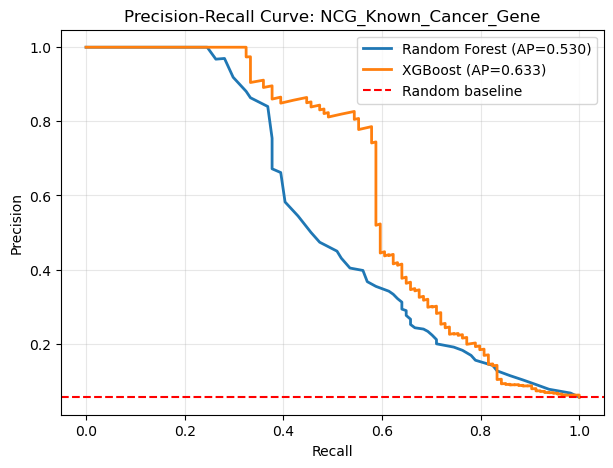

In [64]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [65]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    9351
True      945
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [19:09:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


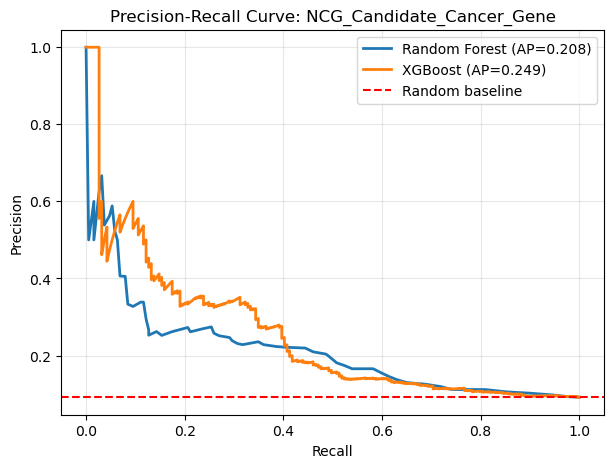

In [66]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [67]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    9831
True      465
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [19:10:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


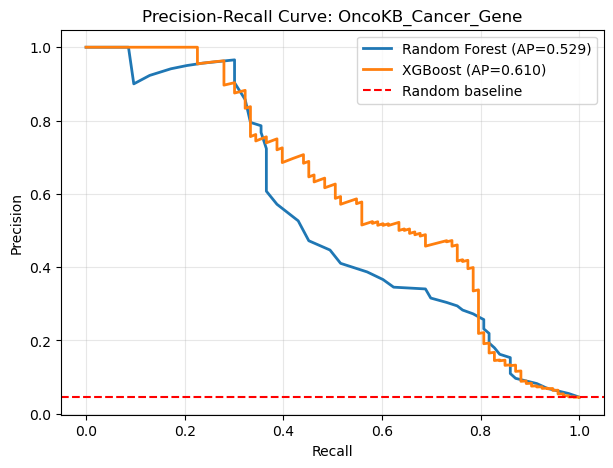

In [68]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [69]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    10050
True       246
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [19:11:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


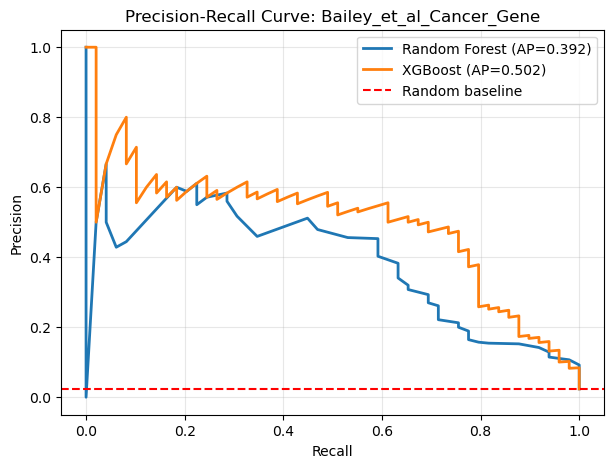

In [70]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')